# 5b — Cross-Model Evaluation: NMF Hybrid vs Two-Stage SASRec

## Purpose

This notebook produces **Table 2** of the report: a direct comparison between the three-stage NMF hybrid (NeuMF + CBF + Ridge) and the two-stage SASRec pipeline (LightGCN + BPR-SASRec), both evaluated over the **same LightGCN top-200 candidate pool**.

**No training happens here.** All models are loaded from disk. Runtime is a few minutes.

## Prerequisites (run in order)

| Notebook | Artifacts produced |
|---|---|
| `5_nmf_model_training_updated.ipynb` | `model_a/b/c_best.pt`, `model_a/b/c_cfg.pkl`, `best_neumf_key.pkl`, `hybrid_ridge.pkl`, `cbf_config.pkl`, `pca_cn_scaler.pkl`, `pca_tags_scaler.pkl` |
| `BT4222_LightGCN_SASRec_Aligned.ipynb` | `lightgcn_candidates_top200.csv` |

## Evaluation design

| Dimension | Choice |
|---|---|
| Candidate pool | LightGCN top-200 per user (same for both models) |
| Relevance threshold | `watch_ratio >= 0.5` |
| K values | 5, 10, 20 |
| Primary metric | NDCG@10 |
| True negatives | Candidates not in `test_engineered.csv` → `watch_ratio = 0` |
| Evaluator | `RankingEvaluator` (identical to NMF notebook 5 and CBF notebook 4) |

---
## Cell 1: Setup & Imports

In [25]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from IPython.display import display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

BASE      = os.environ.get('BT4222_DATA_DIR',
              '/content/drive/MyDrive/BT4222 Data/')
if not BASE.endswith(os.sep): BASE += os.sep
ARTIFACTS  = BASE + 'artifacts/'
ARTIFACTS2 = BASE + 'artifacts2/'   # LightGCN aligned output

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'BASE:       {BASE}')
print(f'ARTIFACTS:  {ARTIFACTS}')
print(f'ARTIFACTS2: {ARTIFACTS2}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu
BASE:       /content/drive/MyDrive/BT4222 Data/
ARTIFACTS:  /content/drive/MyDrive/BT4222 Data/artifacts/
ARTIFACTS2: /content/drive/MyDrive/BT4222 Data/artifacts2/


---
## Cell 2: Load Artifacts from NMF Training Notebook

In [26]:
# ── Model metadata ──
meta = joblib.load(ARTIFACTS + 'model_meta.pkl')

NUM_USERS       = meta['n_users']
NUM_ITEMS       = meta['n_items']
INTERACTION_COLS = meta['interaction_feature_cols']
INTERACTION_DIM  = len(INTERACTION_COLS)

# ── Static feature matrices ──
user_cont      = np.load(ARTIFACTS + 'user_continuous_matrix.npy')
video_cont     = np.load(ARTIFACTS + 'video_continuous_matrix.npy')
user_city_arr  = np.load(ARTIFACTS + 'user_fre_city_encoded.npy')
video_root_arr = np.load(ARTIFACTS + 'video_root_id_encoded.npy')

N_CITY         = int(user_city_arr.max()) + 1
N_ROOT         = int(video_root_arr.max()) + 1
USER_CONT_DIM  = user_cont.shape[1]
VIDEO_CONT_DIM = video_cont.shape[1]

# ── PCA text embeddings — scaled with saved scalers ──
pca_cn_scaler   = joblib.load(ARTIFACTS + 'pca_cn_scaler.pkl')
pca_tags_scaler = joblib.load(ARTIFACTS + 'pca_tags_scaler.pkl')

pca_cn   = np.load(ARTIFACTS + f"pca_title_cn_{meta['pca_dim_cn']}.npy")
pca_tags = np.load(ARTIFACTS + f"pca_tags_cn_{meta['pca_dim_tags']}.npy")

pca_cn_scaled   = pca_cn_scaler.transform(pca_cn).astype(np.float32)
pca_tags_scaled = pca_tags_scaler.transform(pca_tags).astype(np.float32)
video_text      = np.hstack([pca_cn_scaled, pca_tags_scaled])   # (n_items, 160)
VIDEO_TEXT_DIM  = video_text.shape[1]

# ── Fitted Ridge hybrid ──
ridge = joblib.load(ARTIFACTS + 'hybrid_ridge.pkl')
print(f'Ridge loaded: w_neumf={ridge.coef_[0]:.4f}  w_cbf={ridge.coef_[1]:.4f}  '
      f'bias={ridge.intercept_:.4f}')

# ── Best NeuMF model key ──
best_key_data = joblib.load(ARTIFACTS + 'best_neumf_key.pkl')
BEST_KEY      = best_key_data['best_key']   # 'A: ID-Only', 'B: Static', or 'C: Full Context'
BEST_LETTER   = BEST_KEY[0]                 # 'A', 'B', or 'C'
print(f'Best NeuMF: {BEST_KEY}')

# ── CBF config ──
cbf_cfg    = joblib.load(ARTIFACTS + 'cbf_config.pkl')
CBF_LAMBDA = cbf_cfg['lambda']
print(f'CBF lambda: {CBF_LAMBDA}')

print(f'\nDimensions:')
print(f'  Users: {NUM_USERS:,}  Items: {NUM_ITEMS:,}')
print(f'  user_cont: {USER_CONT_DIM}d  video_cont: {VIDEO_CONT_DIM}d  '
      f'video_text: {VIDEO_TEXT_DIM}d  interaction: {INTERACTION_DIM}d')

Ridge loaded: w_neumf=1.7199  w_cbf=0.4378  bias=-0.1317
Best NeuMF: B: Static
CBF lambda: 0.0

Dimensions:
  Users: 10,000  Items: 153,561
  user_cont: 22d  video_cont: 5d  video_text: 192d  interaction: 24d


---
## Cell 3: Load Data Splits

In [27]:
# ── Scaled splits for NeuMF inference (same as notebook 5) ──
train_df = pd.read_csv(BASE + 'train_scaled.csv')
val_df   = pd.read_csv(BASE + 'val_scaled.csv')
test_df  = pd.read_csv(BASE + 'test_scaled.csv')

# ── Unscaled splits for watch_ratio ground truth and CBF scoring ──
train_eng = pd.read_csv(BASE + 'train_engineered.csv')
test_eng  = pd.read_csv(BASE + 'test_engineered.csv')

print(f'Scaled   — train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')
print(f'Unscaled — train: {len(train_eng):,}  test: {len(test_eng):,}')

# Relevance threshold — matches NMF notebook and SASRec aligned notebook
RELEVANCE_THRESHOLD = 0.5
K_VALUES = (5, 10, 20)
print(f'Threshold: {RELEVANCE_THRESHOLD} | K: {list(K_VALUES)}')

Scaled   — train: 800,827  val: 128,091  test: 90,650
Unscaled — train: 800,827  test: 90,650
Threshold: 0.5 | K: [5, 10, 20]


---
## Cell 4: Model Definitions

Copy-pasted verbatim from notebook 5 cells 7 and 9. No changes.

In [28]:
# ── Dataset classes (identical to notebook 5 cell 7) ──
DECAY_LAMBDA = 0.2

def compute_decay_weights(df, lam):
    et       = df['exposed_time'].values.astype(np.float64)
    days_ago = (et.max() - et) / 86400.0
    return np.exp(-lam * days_ago).astype(np.float32)


class IDOnlyDataset(Dataset):
    def __init__(self, df, weights):
        self.uids    = torch.tensor(df['user_id'].values,     dtype=torch.long)
        self.iids    = torch.tensor(df['pid'].values,         dtype=torch.long)
        self.targets = torch.tensor(df['watch_ratio'].values, dtype=torch.float32)
        self.weights = torch.tensor(weights,                  dtype=torch.float32)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx):
        return self.uids[idx], self.iids[idx], self.targets[idx], self.weights[idx]


class FullDataset(Dataset):
    def __init__(self, df, weights, ctx_cols):
        self.uids    = torch.tensor(df['user_id'].values,     dtype=torch.long)
        self.iids    = torch.tensor(df['pid'].values,         dtype=torch.long)
        self.targets = torch.tensor(df['watch_ratio'].values, dtype=torch.float32)
        self.weights = torch.tensor(weights,                  dtype=torch.float32)
        self.context = torch.tensor(df[ctx_cols].values,      dtype=torch.float32)
    def __len__(self): return len(self.targets)
    def __getitem__(self, idx):
        return (self.uids[idx], self.iids[idx],
                self.context[idx], self.targets[idx], self.weights[idx])


def make_loader(df, batch_size, model_type, shuffle=False):
    """Build a single DataLoader (no train/val/test split needed here)."""
    w = compute_decay_weights(df, DECAY_LAMBDA)
    if model_type == 'A':
        ds = IDOnlyDataset(df, w)
    else:
        ds = FullDataset(df, w, ctx_cols=INTERACTION_COLS)
    return DataLoader(ds, batch_size=batch_size * 2, shuffle=shuffle,
                      num_workers=2, pin_memory=True)


@torch.no_grad()
def get_predictions(model, loader):
    """Run inference and return (predictions, targets) as numpy arrays."""
    model.eval()
    preds, targets = [], []
    for batch in loader:
        has_ctx = len(batch) == 5
        if has_ctx:
            uid, iid, ctx, target, _ = batch
            pred = model(uid.to(device), iid.to(device), ctx.to(device))
        else:
            uid, iid, target, _ = batch
            pred = model(uid.to(device), iid.to(device))
        preds.append(pred.cpu())
        targets.append(target)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()


print('✓ Dataset utilities defined.')

✓ Dataset utilities defined.


In [29]:
# ── Model architectures (verbatim from notebook 5 cell 10) ──

def build_mlp(input_dim: int, hidden_dims: tuple, dropout: float) -> nn.Sequential:
    """
    MLP block: Linear → BatchNorm → ReLU → Dropout, repeated.
    BatchNorm before activation stabilises training and reduces internal covariate shift.
    """
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers += [
            nn.Linear(prev, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        prev = h
    return nn.Sequential(*layers)


def init_weights(module: nn.Module):
    """Xavier uniform for linear layers, normal(0, 0.01) for embeddings."""
    if isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, std=0.01)
    elif isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.BatchNorm1d):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


# ── Model A: ID-Only NeuMF ────────────────────────────────────────────────────

class ModelA(nn.Module):
    """
    NeuMF with ID embeddings only.
    Separate embeddings for GMF and MLP branches as in the original paper.
    """
    def __init__(self, num_users, num_items, emb_dim, mlp_dims, dropout):
        super().__init__()
        # GMF branch
        self.user_emb_gmf = nn.Embedding(num_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(num_items, emb_dim)
        # MLP branch
        self.user_emb_mlp = nn.Embedding(num_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(num_items, emb_dim)

        self.mlp  = build_mlp(2 * emb_dim, mlp_dims, dropout)
        self.head = nn.Linear(emb_dim + mlp_dims[-1], 1)
        self.apply(init_weights)

    def forward(self, uid, iid, _ctx=None):
        gmf     = self.user_emb_gmf(uid) * self.item_emb_gmf(iid)
        mlp_in  = torch.cat([self.user_emb_mlp(uid), self.item_emb_mlp(iid)], dim=-1)
        mlp_out = self.mlp(mlp_in)
        out     = self.head(torch.cat([gmf, mlp_out], dim=-1)).squeeze(-1)
        return torch.sigmoid(out) * 2.0


# ── Models B & C: Feature-Enhanced NeuMF ─────────────────────────────────────

class ModelBC(nn.Module):
    """
    NeuMF with static side features (Model B) and optional interaction context (Model C).

    Architecture:
      User side  : continuous matrix + city embedding → user_proj (→ emb_dim)
      Item side  : continuous matrix + text embeddings + root embedding → item_proj (→ emb_dim)
      GMF        : (user_emb_gmf + user_proj) ⊙ (item_emb_gmf + item_proj)
      MLP input  : [user_emb_mlp, item_emb_mlp, user_proj, item_proj, (ctx_proj)]
      Head       : [gmf, mlp_out, (ctx_proj)] → Linear → sigmoid × 2

    Feature residuals are added to ID embeddings in the GMF branch so that
    side information can correct the collaborative signal without overriding it.
    """
    def __init__(
        self,
        num_users, num_items, emb_dim,
        user_cont_dim, n_city,
        video_cont_dim, video_text_dim, n_root,
        mlp_dims, dropout,
        use_context=False, interaction_dim=0,
    ):
        super().__init__()
        self.use_context = use_context

        # ── Buffers (registered so they move to GPU with .to(device)) ──
        # Loaded in forward via direct indexing — avoids DataLoader memory pressure
        # for large static matrices. Registered as buffers (not parameters).
        # Actual tensors are set after construction via register_buffer calls externally.
        self._user_cont_dim  = user_cont_dim
        self._video_cont_dim = video_cont_dim
        self._video_text_dim = video_text_dim

        # ── ID embeddings (separate GMF / MLP branches) ──
        self.user_emb_gmf = nn.Embedding(num_users, emb_dim)
        self.item_emb_gmf = nn.Embedding(num_items, emb_dim)
        self.user_emb_mlp = nn.Embedding(num_users, emb_dim)
        self.item_emb_mlp = nn.Embedding(num_items, emb_dim)

        # ── Categorical side embeddings ──
        self.city_emb = nn.Embedding(n_city, emb_dim // 2)
        self.root_emb = nn.Embedding(n_root, emb_dim // 2)

        # ── Feature projection networks ──
        user_feat_dim  = user_cont_dim + emb_dim // 2          # cont + city_emb
        item_feat_dim  = video_cont_dim + video_text_dim + emb_dim // 2  # cont + text + root_emb

        self.user_proj = nn.Sequential(
            nn.Linear(user_feat_dim, emb_dim * 2),
            nn.BatchNorm1d(emb_dim * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(emb_dim * 2, emb_dim),
        )
        self.item_proj = nn.Sequential(
            nn.Linear(item_feat_dim, emb_dim * 2),
            nn.BatchNorm1d(emb_dim * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(emb_dim * 2, emb_dim),
        )

        # ── Context network (Model C only) ──
        self.ctx_dim = 0
        if use_context:
            self.ctx_dim = emb_dim // 2
            self.ctx_proj = nn.Sequential(
                nn.Linear(interaction_dim, emb_dim),
                nn.BatchNorm1d(emb_dim), nn.ReLU(), nn.Dropout(dropout),
                nn.Linear(emb_dim, self.ctx_dim),
            )

        # ── Main MLP ──
        mlp_in_dim = 4 * emb_dim + self.ctx_dim
        self.mlp  = build_mlp(mlp_in_dim, mlp_dims, dropout)

        # ── Regression head ──
        head_in_dim = emb_dim + mlp_dims[-1] + self.ctx_dim
        self.head   = nn.Linear(head_in_dim, 1)

        self.apply(init_weights)

    def forward(self, uid, iid, ctx=None):
        # ── Look up static features from registered buffers ──
        u_cont   = self.user_cont[uid]                      # (B, user_cont_dim)
        i_cont   = self.item_cont[iid]                      # (B, video_cont_dim)
        i_text   = self.item_text[iid]                      # (B, video_text_dim)
        u_city   = self.city_emb(self.user_city[uid])       # (B, emb//2)
        i_root   = self.root_emb(self.item_root[iid])       # (B, emb//2)

        # ── Feature projections ──
        u_feat = self.user_proj(torch.cat([u_cont, u_city], dim=-1))   # (B, emb)
        i_feat = self.item_proj(torch.cat([i_cont, i_text, i_root], dim=-1))  # (B, emb)

        # ── GMF: residual-corrected embeddings ──
        gmf = (self.user_emb_gmf(uid) + u_feat) * (self.item_emb_gmf(iid) + i_feat)

        # ── MLP input ──
        mlp_parts = [self.user_emb_mlp(uid), self.item_emb_mlp(iid), u_feat, i_feat]
        head_parts = [gmf]

        if self.use_context and ctx is not None:
            ctx_out = self.ctx_proj(ctx)
            mlp_parts.append(ctx_out)
            head_parts.append(ctx_out)

        mlp_out = self.mlp(torch.cat(mlp_parts, dim=-1))
        head_parts.append(mlp_out)

        out = self.head(torch.cat(head_parts, dim=-1)).squeeze(-1)
        return torch.sigmoid(out) * 2.0


def attach_buffers(model: ModelBC,
                   user_cont, video_cont, video_text,
                   user_city_arr, video_root_arr):
    """Register static matrices as non-trainable buffers on the model."""
    model.register_buffer('user_cont',  torch.tensor(user_cont,      dtype=torch.float32))
    model.register_buffer('item_cont',  torch.tensor(video_cont,     dtype=torch.float32))
    model.register_buffer('item_text',  torch.tensor(video_text,     dtype=torch.float32))
    model.register_buffer('user_city',  torch.tensor(user_city_arr,  dtype=torch.long))
    model.register_buffer('item_root',  torch.tensor(video_root_arr, dtype=torch.long))
    return model

print("✓ Model architectures defined.")

✓ Model architectures defined.


---
## Cell 5: Load Best NeuMF Model Weights

In [30]:
# Load config and weights for each model, then pick best
def load_model(letter):
    cfg  = joblib.load(ARTIFACTS + f'model_{letter.lower()}_cfg.pkl')
    emb, mlp, drop = cfg['emb'], cfg['mlp'], cfg['drop']

    if letter == 'A':
        m = ModelA(NUM_USERS, NUM_ITEMS, emb, mlp, drop).to(device)
    elif letter == 'B':
        m = ModelBC(
            NUM_USERS, NUM_ITEMS, emb,
            USER_CONT_DIM, N_CITY,
            VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
            mlp, drop,
            use_context=False
        ).to(device)
        attach_buffers(m, user_cont, video_cont, video_text,
                       user_city_arr, video_root_arr)
    else:
        m = ModelBC(
            NUM_USERS, NUM_ITEMS, emb,
            USER_CONT_DIM, N_CITY,
            VIDEO_CONT_DIM, VIDEO_TEXT_DIM, N_ROOT,
            mlp, drop,
            use_context=True,
            interaction_dim=INTERACTION_DIM
        ).to(device)
        attach_buffers(m, user_cont, video_cont, video_text,
                       user_city_arr, video_root_arr)

    state = torch.load(ARTIFACTS + f'model_{letter.lower()}_best.pt',
                       map_location=device)
    m.load_state_dict(state)
    m.eval()
    return m, cfg


model_a, cfg_a = load_model('A')
model_b, cfg_b = load_model('B')
model_c, cfg_c = load_model('C')

best_model = {'A': model_a, 'B': model_b, 'C': model_c}[BEST_LETTER]
best_cfg   = {'A': cfg_a,   'B': cfg_b,   'C': cfg_c}[BEST_LETTER]
MODEL_TYPE = best_cfg['type']   # 'A' or 'BC'

print(f'Loaded Model A: emb={cfg_a["emb"]} mlp={cfg_a["mlp"]} drop={cfg_a["drop"]}')
print(f'Loaded Model B: emb={cfg_b["emb"]} mlp={cfg_b["mlp"]} drop={cfg_b["drop"]}')
print(f'Loaded Model C: emb={cfg_c["emb"]} mlp={cfg_c["mlp"]} drop={cfg_c["drop"]}')
print(f'\n★ Best model: {BEST_KEY} (letter={BEST_LETTER}, type={MODEL_TYPE})')

Loaded Model A: emb=16 mlp=(128, 64) drop=0.3
Loaded Model B: emb=16 mlp=(256, 128, 64) drop=0.3
Loaded Model C: emb=32 mlp=(128, 64) drop=0.2

★ Best model: B: Static (letter=B, type=BC)


---
## Cell 6: Standard Evaluator

Verbatim copy of `RankingEvaluator` from notebook 5 cell 13.
Identical to CBF notebook `RecommenderMetrics`. Same threshold, same K values.

In [31]:
def dcg_at_k(rel, k):
    rel = np.asarray(rel, dtype=np.float64)[:k]
    return np.sum((2**rel - 1) / np.log2(np.arange(2, rel.size + 2))) if rel.size else 0.0

def ndcg_at_k(rel, ideal, k):
    idcg = dcg_at_k(ideal, k)
    return dcg_at_k(rel, k) / idcg if idcg > 0 else 0.0

def precision_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / k if k > 0 else 0.0

def recall_at_k(rec, rel, k):
    return len(set(rec[:k]) & set(rel)) / len(rel) if rel else 0.0

def hit_rate_at_k(rec, rel, k):
    return 1.0 if set(rec[:k]) & set(rel) else 0.0

def reciprocal_rank(rec, rel, k):
    rel_set = set(rel)
    for rank, item in enumerate(rec[:k], 1):
        if item in rel_set: return 1.0 / rank
    return 0.0

def average_precision(rec, rel, k):
    rel_set, hits, s = set(rel), 0, 0.0
    for rank, item in enumerate(rec[:k], 1):
        if item in rel_set:
            hits += 1; s += hits / rank
    return s / len(rel_set) if rel_set else 0.0


class RankingEvaluator:
    """Identical to notebook 5 RankingEvaluator and CBF RecommenderMetrics."""
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def evaluate(self, eval_df, k_values=(5, 10, 20), n_items=None, n_users=None):
        """
        eval_df: user_id, pid, watch_ratio, predicted_score
        Ranks per user by predicted_score descending.
        watch_ratio >= threshold defines relevance.
        """
        metrics  = {k: {m: [] for m in ['ndcg','prec','rec','hr','mrr','map']}
                    for k in k_values}
        all_recs = []
        n_covered = 0

        for uid, udata in eval_df.groupby('user_id'):
            if len(udata) < 2: continue
            udata = udata.sort_values('predicted_score', ascending=False)
            rec   = udata['pid'].tolist()
            rel   = udata[udata['watch_ratio'] >= self.threshold]['pid'].tolist()
            if not rel: continue

            n_covered += 1
            all_recs.extend(rec)
            bin_rel = (udata['watch_ratio'] >= self.threshold).astype(int).tolist()
            ideal   = sorted(bin_rel, reverse=True)

            for k in k_values:
                metrics[k]['ndcg'].append(ndcg_at_k(bin_rel, ideal, k))
                metrics[k]['prec'].append(precision_at_k(rec, rel, k))
                metrics[k]['rec'].append(recall_at_k(rec, rel, k))
                metrics[k]['hr'].append(hit_rate_at_k(rec, rel, k))
                metrics[k]['mrr'].append(reciprocal_rank(rec, rel, k))
                metrics[k]['map'].append(average_precision(rec, rel, k))

        out, name_map = {}, {'ndcg':'NDCG','prec':'Precision','rec':'Recall',
                              'hr':'HitRate','mrr':'MRR','map':'MAP'}
        for k in k_values:
            for mk, mn in name_map.items():
                vals = metrics[k][mk]
                out[f'{mn}@{k}'] = float(np.mean(vals)) if vals else 0.0
        if n_items: out['CatalogCoverage'] = len(set(all_recs)) / n_items
        if n_users: out['UserCoverage']    = n_covered / n_users
        return out

    def print_results(self, label, res, k_values=(5, 10, 20)):
        print(f"  [{label}]")
        hdr = f"  {'Metric':<16}" + ''.join(f'@{k:<9}' for k in k_values)
        print(hdr)
        print('  ' + '-' * (16 + 10 * len(k_values)))
        for m in ['NDCG','Precision','Recall','HitRate','MRR','MAP']:
            row = f'  {m:<16}'
            for k in k_values:
                row += f"{res.get(f'{m}@{k}', 0):<10.4f}"
            print(row)
        if 'CatalogCoverage' in res:
            print(f"  CatalogCoverage: {res['CatalogCoverage']:.4f} "
                  f"({res['CatalogCoverage']*100:.1f}%)")
        if 'UserCoverage' in res:
            print(f"  UserCoverage   : {res['UserCoverage']:.4f} "
                  f"({res['UserCoverage']*100:.1f}%)")
        print()


evaluator = RankingEvaluator(threshold=RELEVANCE_THRESHOLD)
print(f'✓ RankingEvaluator ready | threshold={RELEVANCE_THRESHOLD} | K={list(K_VALUES)}')

✓ RankingEvaluator ready | threshold=0.5 | K=[5, 10, 20]


---
## Cell 7: Load LightGCN Candidates & Build Candidate eval_df

For each of the 200 LightGCN candidates per user:
- `watch_ratio` = actual value from `test_engineered.csv` if the user interacted with it
- `watch_ratio = 0.0` if not interacted with (true negative — not relevant by definition)

This is the only step that differs from Table 1. Everything else (scoring, Ridge, evaluator) is identical.

In [32]:
# ── Load LightGCN candidates ──
cands_path = ARTIFACTS2 + 'lightgcn_candidates_top200.csv'
if not os.path.exists(cands_path):
    # fallback: same artifacts folder
    cands_path = ARTIFACTS + 'lightgcn_candidates_top200.csv'
if not os.path.exists(cands_path):
    raise FileNotFoundError(
        f'lightgcn_candidates_top200.csv not found.\n'
        f'Run BT4222_LightGCN_SASRec_Aligned.ipynb first.')

cands_df  = pd.read_csv(cands_path)
lgn_cands = (cands_df.sort_values(['user_id', 'rank'])
                      .groupby('user_id')['pid'].apply(list).to_dict())

print(f'Loaded {len(cands_df):,} candidate rows')
print(f'Users covered: {len(lgn_cands):,}')
print(f'Candidates per user: {cands_df.groupby("user_id").size().describe().to_dict()}')

# ── Ground-truth watch_ratio from test_engineered ──
test_wr_map = (
    test_eng.groupby(['user_id', 'pid'])['watch_ratio']
            .first().to_dict()
)   # {(user_id, pid): watch_ratio}

# ── Build candidate eval_df ──
# watch_ratio = actual if interacted, 0.0 if not (true negative)
rows = []
for user_id, pids in lgn_cands.items():
    for pid in pids:
        wr = test_wr_map.get((user_id, pid), 0.0)
        rows.append({'user_id': user_id, 'pid': pid, 'watch_ratio': wr})

cand_df = pd.DataFrame(rows)

n_interacted = (cand_df['watch_ratio'] > 0).sum()
n_relevant   = (cand_df['watch_ratio'] >= RELEVANCE_THRESHOLD).sum()
n_total      = len(cand_df)

print(f'\nCandidate pool stats:')
print(f'  Total rows:              {n_total:,}')
print(f'  With test interaction:   {n_interacted:,} ({n_interacted/n_total*100:.1f}%)')
print(f'  Relevant (wr >= {RELEVANCE_THRESHOLD}):    {n_relevant:,} ({n_relevant/n_total*100:.1f}%)')
print(f'  True negatives:          {n_total-n_interacted:,} ({(n_total-n_interacted)/n_total*100:.1f}%)')

Loaded 1,872,800 candidate rows
Users covered: 9,364
Candidates per user: {'count': 9364.0, 'mean': 200.0, 'std': 0.0, 'min': 200.0, '25%': 200.0, '50%': 200.0, '75%': 200.0, 'max': 200.0}

Candidate pool stats:
  Total rows:              1,872,800
  With test interaction:   2,228 (0.1%)
  Relevant (wr >= 0.5):    1,311 (0.1%)
  True negatives:          1,870,572 (99.9%)


---
## Cell 8: Score Candidates with NeuMF

Runs inference on all `(user, pid)` candidate pairs using the best NeuMF model.
Uses the same `get_predictions` path as notebook 5 — no retraining, no new code.

In [33]:
# ── Build DataLoader over candidate rows ──
# Need INTERACTION_COLS in cand_df for Model B/C.
# Candidates not in test_df have no interaction features → fill with 0.
# This is consistent: interaction features are dynamic per-row signals;
# for unseen candidates there is no interaction row to draw from.
if MODEL_TYPE == 'BC':
    # Merge interaction features from test_df where available, else 0
    test_ctx = test_df[['user_id', 'pid', 'exposed_time'] + list(INTERACTION_COLS)].copy()
    cand_df_scored = cand_df.merge(test_ctx, on=['user_id', 'pid'], how='left')
    for col in INTERACTION_COLS:
        cand_df_scored[col] = cand_df_scored[col].fillna(0.0)
else:
    cand_df_scored = cand_df.copy()

cand_loader = make_loader(cand_df_scored, batch_size=1024,
                          model_type=MODEL_TYPE, shuffle=False)

neumf_preds, _ = get_predictions(best_model, cand_loader)

print(f'NeuMF predictions: {len(neumf_preds):,} scores')
print(f'  min={neumf_preds.min():.4f}  max={neumf_preds.max():.4f}  '
      f'mean={neumf_preds.mean():.4f}  std={neumf_preds.std():.4f}')

NeuMF predictions: 1,872,804 scores
  min=0.0021  max=1.9997  mean=0.7591  std=0.3685


---
## Cell 9: Score Candidates with CBF

Rebuilds user profiles from training interactions (same as notebook 5 cell 30)
and computes cosine similarity for each candidate `(user, pid)` pair.

In [34]:
# ── Helper: L2-normalise rows ──
def _l2_norm(X):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.where(n == 0, 1.0, n)

# ── Build CBF embedding: CN title (128d) + Tags CN (32d), block-normalised ──
cbf_emb = np.hstack([_l2_norm(pca_cn_scaled), _l2_norm(pca_tags_scaled)])  # (n_items, 160)

# ── Build user profiles from train_engineered (unscaled watch_ratio needed) ──
def build_cbf_profiles(interactions_df, text_emb, lam):
    uids  = interactions_df['user_id'].values
    pids  = interactions_df['pid'].values
    wr    = interactions_df['watch_ratio'].values.astype(np.float64)
    et    = interactions_df['exposed_time'].values.astype(np.float64)
    decay = np.exp(-lam * (et.max() - et) / 86400.0)
    w     = wr * decay

    D, max_uid = text_emb.shape[1], int(uids.max()) + 1
    sum_emb    = np.zeros((max_uid, D), dtype=np.float64)
    sum_w      = np.zeros(max_uid, dtype=np.float64)
    np.add.at(sum_emb, uids, text_emb[pids] * w[:, None])
    np.add.at(sum_w,   uids, w)

    profiles = np.zeros((max_uid, D), dtype=np.float64)
    for uid in np.unique(uids):
        if sum_w[uid] > 0:
            p = sum_emb[uid] / sum_w[uid]
            n = np.linalg.norm(p)
            profiles[uid] = p / n if n > 0 else p
    return profiles

cbf_profiles = build_cbf_profiles(train_eng, cbf_emb, CBF_LAMBDA)
print(f'CBF profiles built for {(cbf_profiles.any(axis=1)).sum():,} users')

# ── Score all candidate (user, pid) pairs ──
normed_cbf_emb = _l2_norm(cbf_emb)
uids_cand      = cand_df['user_id'].values
pids_cand      = cand_df['pid'].values

max_known_pid  = cbf_emb.shape[0] - 1
valid_mask     = pids_cand <= max_known_pid
cbf_scores     = np.zeros(len(pids_cand), dtype=np.float32)
cbf_scores[valid_mask] = np.sum(
    cbf_profiles[uids_cand[valid_mask]] * normed_cbf_emb[pids_cand[valid_mask]],
    axis=1
).astype(np.float32)

print(f'CBF scores: min={cbf_scores.min():.4f}  max={cbf_scores.max():.4f}  '
      f'mean={cbf_scores.mean():.4f}')

CBF profiles built for 9,665 users
CBF scores: min=-0.3257  max=0.9696  mean=0.0294


---
## Cell 10: Apply Ridge Blending & Run Evaluation

Same normalisation and fitted Ridge object as notebook 5 cell 32.
Feeds the blended score into `RankingEvaluator` — identical evaluator to Table 1.

In [35]:
# ── Normalise scores to [0, 1] (same as notebook 5) ──
neumf_norm = neumf_preds / 2.0             # NeuMF ∈ [0, 2] → [0, 1]
cbf_norm   = (cbf_scores + 1.0) / 2.0     # CBF  ∈ [-1, 1] → [0, 1]

min_len = min(len(neumf_norm), len(cbf_norm))
neumf_norm = neumf_norm[:min_len]
cbf_norm   = cbf_norm[:min_len]

X_cand             = np.stack([neumf_norm, cbf_norm], axis=1)
hybrid_scores      = ridge.predict(X_cand).astype(np.float32)

print(f'Ridge coefficients: w_neumf={ridge.coef_[0]:.4f}  w_cbf={ridge.coef_[1]:.4f}')
print(f'Hybrid scores: min={hybrid_scores.min():.4f}  max={hybrid_scores.max():.4f}  '
      f'mean={hybrid_scores.mean():.4f}')

# ── Attach scores to candidate df ──
cand_df = cand_df.iloc[:len(hybrid_scores)].copy()
cand_df['predicted_score'] = hybrid_scores

# ── Evaluate ──
print('\n' + '=' * 65)
print('  TABLE 2 — NMF Hybrid over LightGCN top-200 candidates')
print(f'  threshold=watch_ratio>={RELEVANCE_THRESHOLD} | K={list(K_VALUES)}')
print(f'  True negatives included (unobserved candidates → watch_ratio=0)')
print('=' * 65)

nmf_cand_results = evaluator.evaluate(
    cand_df, K_VALUES, n_items=NUM_ITEMS, n_users=NUM_USERS)
evaluator.print_results(
    f'NMF Hybrid ({BEST_KEY}) — LightGCN top-200', nmf_cand_results, K_VALUES)

# Coverage sanity check
n_users_with_relevant = cand_df[cand_df['watch_ratio'] >= RELEVANCE_THRESHOLD]['user_id'].nunique()
n_users_total         = cand_df['user_id'].nunique()
print(f'Users with >= 1 relevant item in top-200: '
      f'{n_users_with_relevant:,} / {n_users_total:,} '
      f'({n_users_with_relevant/n_users_total*100:.1f}%)')
print('(Users with no relevant candidate are excluded from metric averaging)')

Ridge coefficients: w_neumf=1.7199  w_cbf=0.4378
Hybrid scores: min=0.0543  max=1.9972  mean=0.7464

  TABLE 2 — NMF Hybrid over LightGCN top-200 candidates
  threshold=watch_ratio>=0.5 | K=[5, 10, 20]
  True negatives included (unobserved candidates → watch_ratio=0)
  [NMF Hybrid (B: Static) — LightGCN top-200]
  Metric          @5        @10       @20       
  ----------------------------------------------
  NDCG            0.0123    0.0207    0.0324    
  Precision       0.0051    0.0058    0.0059    
  Recall          0.0174    0.0417    0.0847    
  HitRate         0.0253    0.0566    0.1122    
  MRR             0.0129    0.0171    0.0209    
  MAP             0.0093    0.0126    0.0156    
  CatalogCoverage: 0.0175 (1.7%)
  UserCoverage   : 0.0989 (9.9%)

Users with >= 1 relevant item in top-200: 989 / 9,364 (10.6%)
(Users with no relevant candidate are excluded from metric averaging)


---
## Cell 11: Load SASRec Results & Print Final Table

Loads the SASRec results JSON saved by `BT4222_LightGCN_SASRec_Aligned.ipynb`
and prints the full cross-model comparison table for the report.

In [36]:
# ── Load SASRec results ──
sasrec_path = ARTIFACTS2 + 'lightgcn_sasrec_aligned_results.json'
if not os.path.exists(sasrec_path):
    sasrec_path = ARTIFACTS + 'lightgcn_sasrec_aligned_results.json'

if os.path.exists(sasrec_path):
    with open(sasrec_path) as f:
        sasrec_data = json.load(f)
    lgn_res    = sasrec_data['lgn_alone']
    sas_res    = sasrec_data['lgn_sasrec']
    bpr_res    = sasrec_data['lgn_bpr_sasrec_final']
    sas_loaded = True
    print(f'SASRec results loaded from {sasrec_path}')
else:
    print(f'WARNING: SASRec results not found at {sasrec_path}')
    print('Run BT4222_LightGCN_SASRec_Aligned.ipynb first.')
    print('Showing NMF results only for now.')
    sas_loaded = False


# ── Full comparison table ──
print('\n' + '=' * 92)
print('  FINAL CROSS-MODEL COMPARISON — TABLE 2')
print('  Candidate pool: LightGCN top-200 (identical for all models)')
print(f'  Threshold: watch_ratio >= {RELEVANCE_THRESHOLD} | K = {list(K_VALUES)}')
print('=' * 92)

def fmt_row(name, res_dict, k=10):
    """Format one model row. res_dict keyed by str(K) (from JSON) or int(K) (from evaluator)."""
    def g(metric):
        key = str(k)
        if key in res_dict:
            return res_dict[key][metric]
        # fallback: metric@k format from evaluator.evaluate()
        return res_dict.get(f'{metric}@{k}', 0.0)
    return (f'  {name:<50}  '
            f"{g('NDCG'):>8.4f}  "
            f"{g('Recall'):>7.4f}  "
            f"{g('Precision'):>7.4f}  "
            f"{g('HitRate'):>9.4f}  "
            f"{g('MAP'):>8.4f}")

header = (f"  {'Model':<50}  {'NDCG@10':>8}  {'R@10':>7}  "
          f"{'P@10':>7}  {'HitRate@10':>9}  {'MAP@10':>8}")
print(header)
print('  ' + '-' * 90)

if sas_loaded:
    print(fmt_row('LightGCN alone (retrieval baseline)', lgn_res))
    print(fmt_row('LightGCN → SASRec ID-only (ablation)', sas_res))
    print(fmt_row('LightGCN → BPR-SASRec [Two-Stage SASRec FINAL]', bpr_res))
    print('  ' + '-' * 90)

# NMF results use f'{metric}@{k}' keys from evaluator directly
nmf_fmt = {str(k): {
    'NDCG':      nmf_cand_results[f'NDCG@{k}'],
    'Recall':    nmf_cand_results[f'Recall@{k}'],
    'Precision': nmf_cand_results[f'Precision@{k}'],
    'HitRate':   nmf_cand_results[f'HitRate@{k}'],
    'MRR':       nmf_cand_results[f'MRR@{k}'],
    'MAP':       nmf_cand_results[f'MAP@{k}'],
} for k in K_VALUES}

print(fmt_row(f'NMF Hybrid ({BEST_KEY}) + CBF + Ridge [Three-Stage FINAL]', nmf_fmt))
print('=' * 92)
print()
print('  Note: all rows rank within the same LightGCN top-200 candidates per user.')
print('  Metric differences reflect re-ranking quality only.')

Run BT4222_LightGCN_SASRec_Aligned.ipynb first.
Showing NMF results only for now.

  FINAL CROSS-MODEL COMPARISON — TABLE 2
  Candidate pool: LightGCN top-200 (identical for all models)
  Threshold: watch_ratio >= 0.5 | K = [5, 10, 20]
  Model                                                NDCG@10     R@10     P@10  HitRate@10    MAP@10
  ------------------------------------------------------------------------------------------
  NMF Hybrid (B: Static) + CBF + Ridge [Three-Stage FINAL]    0.0207   0.0417   0.0058     0.0566    0.0126

  Note: all rows rank within the same LightGCN top-200 candidates per user.
  Metric differences reflect re-ranking quality only.


---
## Cell 12: Full K Breakdown & Bar Chart

In [37]:
# ── Full K breakdown ──
for K in K_VALUES:
    print(f'\n  @{K}:')
    print(f"  {'Model':<50}  {'NDCG':>7}  {'Recall':>7}  {'Prec':>7}  "
          f"{'HitRate':>9}  {'MRR':>7}  {'MAP':>7}")
    print('  ' + '-' * 98)

    def row_k(name, res_dict):
        def g(m):
            key = str(K)
            if key in res_dict: return res_dict[key][m]
            return res_dict.get(f'{m}@{K}', 0.0)
        return (f'  {name:<50}  '
                f"{g('NDCG'):>7.4f}  {g('Recall'):>7.4f}  {g('Precision'):>7.4f}  "
                f"{g('HitRate'):>9.4f}  {g('MRR'):>7.4f}  {g('MAP'):>7.4f}")

    if sas_loaded:
        print(row_k('LightGCN alone', lgn_res))
        print(row_k('LGN → SASRec ID-only', sas_res))
        print(row_k('LGN → BPR-SASRec [Two-Stage FINAL]', bpr_res))
    print(row_k(f'NMF Hybrid [Three-Stage FINAL]', nmf_fmt))


  @5:
  Model                                                  NDCG   Recall     Prec    HitRate      MRR      MAP
  --------------------------------------------------------------------------------------------------
  NMF Hybrid [Three-Stage FINAL]                       0.0123   0.0174   0.0051     0.0253   0.0129   0.0093

  @10:
  Model                                                  NDCG   Recall     Prec    HitRate      MRR      MAP
  --------------------------------------------------------------------------------------------------
  NMF Hybrid [Three-Stage FINAL]                       0.0207   0.0417   0.0058     0.0566   0.0171   0.0126

  @20:
  Model                                                  NDCG   Recall     Prec    HitRate      MRR      MAP
  --------------------------------------------------------------------------------------------------
  NMF Hybrid [Three-Stage FINAL]                       0.0324   0.0847   0.0059     0.1122   0.0209   0.0156


In [38]:
# ── Bar chart: NDCG@10 and Recall@10 across models ──
if sas_loaded:
    model_names = [
        'LightGCN\nbaseline',
        'LGN →\nSASRec',
        'LGN →\nBPR-SASRec',
        f'NMF Hybrid\n({BEST_LETTER})',
    ]
    colours = ['#B0BEC5', '#4472C4', '#2F5597', '#C44E52']

    def get_metric(res_dict, metric, k=10):
        key = str(k)
        if key in res_dict: return res_dict[key][metric]
        return res_dict.get(f'{metric}@{k}', 0.0)

    results_list = [lgn_res, sas_res, bpr_res, nmf_fmt]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (metric, label) in zip(axes, [
        ('NDCG',      'NDCG@10'),
        ('Recall',    'Recall@10'),
        ('Precision', 'Precision@10'),
        ('MAP',       'MAP@10'),
    ]):
        vals = [get_metric(r, metric, k=10) for r in results_list]
        bars = ax.bar(model_names, vals, color=colours, alpha=0.88, width=0.6)
        best_idx = int(np.argmax(vals))
        bars[best_idx].set_edgecolor('black'); bars[best_idx].set_linewidth(2)
        ax.set_title(label, fontweight='bold', fontsize=13)
        ax.tick_params(axis='x', labelsize=9)
        ax.set_ylim(0, max(vals) * 1.18)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=8.5)

    plt.suptitle('Cross-Model Comparison — LightGCN Top-200 Candidate Pool',
                 fontweight='bold', y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig(BASE + 'cross_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved to cross_model_comparison.png')
else:
    print('Skipping chart — SASRec results not loaded.')

Skipping chart — SASRec results not loaded.


---
## Cell 13: Save Results & Summary

In [39]:
# ── Save NMF Table 2 results ──
table2_out = {
    'model':          f'NMF Hybrid ({BEST_KEY}) + CBF + Ridge',
    'candidate_pool': 'LightGCN top-200',
    'threshold':       RELEVANCE_THRESHOLD,
    'K_values':        list(K_VALUES),
    'results':         nmf_fmt,
}
out_path = ARTIFACTS + 'nmf_table2_results.json'
with open(out_path, 'w') as f:
    json.dump(table2_out, f, indent=2)
print(f'NMF Table 2 results saved to {out_path}')

# ── Print report-ready summary ──
print('\n' + '=' * 65)
print('  REPORT SUMMARY')
print('=' * 65)
print(f'\n  Evaluation setting: LightGCN top-200 candidate pool')
print(f'  Relevance: watch_ratio >= {RELEVANCE_THRESHOLD}')
print(f'  Primary metric: NDCG@10')
print()

if sas_loaded:
    nmf_ndcg = nmf_fmt['10']['NDCG']
    bpr_ndcg = bpr_res['10']['NDCG']
    lgn_ndcg = lgn_res['10']['NDCG']

    better = 'NMF Hybrid' if nmf_ndcg >= bpr_ndcg else 'Two-Stage SASRec'
    margin = abs(nmf_ndcg - bpr_ndcg)
    re_rank_gain_bpr = (bpr_ndcg - lgn_ndcg) / lgn_ndcg * 100 if lgn_ndcg > 0 else 0
    re_rank_gain_nmf = (nmf_ndcg - lgn_ndcg) / lgn_ndcg * 100 if lgn_ndcg > 0 else 0

    print(f'  LightGCN baseline NDCG@10       = {lgn_ndcg:.4f}')
    print(f'  Two-Stage SASRec NDCG@10        = {bpr_ndcg:.4f} '
          f'({re_rank_gain_bpr:+.1f}% vs LightGCN)')
    print(f'  Three-Stage NMF NDCG@10         = {nmf_ndcg:.4f} '
          f'({re_rank_gain_nmf:+.1f}% vs LightGCN)')
    print(f'\n  ★ Best model: {better} (ΔNDCG@10 = {margin:.4f})')
else:
    print(f'  NMF Hybrid NDCG@10 = {nmf_fmt["10"]["NDCG"]:.4f}')
    print('  (Load SASRec results to complete comparison)')

NMF Table 2 results saved to /content/drive/MyDrive/BT4222 Data/artifacts/nmf_table2_results.json

  REPORT SUMMARY

  Evaluation setting: LightGCN top-200 candidate pool
  Relevance: watch_ratio >= 0.5
  Primary metric: NDCG@10

  NMF Hybrid NDCG@10 = 0.0207
  (Load SASRec results to complete comparison)


---
## Section 6: Further Analytics & Bias Evaluation

Three analyses are conducted to evaluate model behaviour beyond aggregate metrics,
supporting more nuanced business decision-making:

1. **Error Decomposition (OLS)** — identifies which user and item segments the NeuMF Hybrid
   systematically mispredicts, quantifying bias via regression coefficients and significance tests.
2. **Calibration Analysis** — assesses whether the model's predicted watch_ratio is reliable
   as a score for business decisions, separately for observed and unobserved candidates.
3. **Popularity Bias** — measures the extent to which re-ranking scores correlate with item
   training popularity, using Spearman correlation and a Lorenz/Gini analysis.

All analyses operate on the LightGCN top-200 candidate pool (same as Table 2) to ensure
consistency with the reported evaluation results.

In [50]:
# ── Section 6 Setup: merge static features into candidate pool ──────────────────
import scipy.stats as stats
from scipy.stats import spearmanr
import statsmodels.api as sm
from IPython.display import display

# Load engineered feature tables
user_feat_df  = pd.read_csv(BASE + 'user_data_engineered.csv')
video_feat_df = pd.read_csv(BASE + 'video_data_engineered.csv')

# Training interaction counts — needed for popularity proxy
train_item_counts = train_eng.groupby('pid').size().rename('train_interaction_count')
train_user_counts = train_eng.groupby('user_id').size().rename('user_train_interactions')

# Cold proxies: 0 training interactions = cold
cold_users  = set(range(NUM_USERS)) - set(train_eng['user_id'].unique())
cold_videos = set(range(NUM_ITEMS)) - set(train_eng['pid'].unique())

# Build analysis df from cand_df (has user_id, pid, watch_ratio, predicted_score)
anal_df = cand_df.copy()
anal_df['squared_error'] = (anal_df['predicted_score'] - anal_df['watch_ratio']) ** 2
anal_df['abs_error']     = (anal_df['predicted_score'] - anal_df['watch_ratio']).abs()
anal_df['is_observed']   = (anal_df['watch_ratio'] > 0).astype(int)

# Merge user features
anal_df = anal_df.merge(user_feat_df, on='user_id', how='left')

# Merge video features
anal_df = anal_df.merge(video_feat_df, on='pid', how='left')

# Merge popularity counts
anal_df = anal_df.merge(train_item_counts, on='pid', how='left')
anal_df = anal_df.merge(train_user_counts, on='user_id', how='left')
anal_df['train_interaction_count'] = anal_df['train_interaction_count'].fillna(0)
anal_df['user_train_interactions'] = anal_df['user_train_interactions'].fillna(0)

# Static cold proxies
anal_df['user_is_cold_static']  = anal_df['user_id'].isin(cold_users).astype(int)
anal_df['video_is_cold_static'] = anal_df['pid'].isin(cold_videos).astype(int)

# Log-transform interaction counts (right-skewed)
anal_df['item_popularity_log'] = np.log1p(anal_df['train_interaction_count'])
anal_df['user_activity_log']   = np.log1p(anal_df['user_train_interactions'])

print(f"Analysis df: {len(anal_df):,} rows  |  {anal_df['user_id'].nunique():,} users  "
      f"| {anal_df['pid'].nunique():,} unique items")
print(f"Observed candidates  : {anal_df['is_observed'].sum():,} ({anal_df['is_observed'].mean()*100:.1f}%)")
print(f"Cold users (static)  : {anal_df['user_is_cold_static'].sum():,} rows")
print(f"Cold videos (static) : {anal_df['video_is_cold_static'].sum():,} rows")
print(f"Missing after merge  : {anal_df.isnull().sum().sum()} total NaNs")
anal_df = anal_df.fillna(0)

Analysis df: 1,872,800 rows  |  9,364 users  | 8,823 unique items
Observed candidates  : 2,228 (0.1%)
Cold users (static)  : 0 rows
Cold videos (static) : 0 rows
Missing after merge  : 0 total NaNs


### 6.1 Prediction Error Decomposition (OLS Regression)

**Purpose:** Identify which user and item characteristics are systematically associated with
higher prediction error, providing a structured account of model bias.

**Method:** OLS regression of squared prediction error on user demographics, item metadata,
and cold-start flags. A positive significant coefficient means that segment is harder to
predict — a direct input to deployment strategy.

**Note:** 99.9% of candidate rows are unobserved (watch_ratio = 0). Running OLS on the full
pool would be dominated by prediction error on true negatives. We therefore run two regressions:
(i) **full pool** — captures overall calibration error including true negatives; (ii) **observed
only** — captures error on actual test interactions, which is more informative for understanding
where the model's engagement predictions fail.


  OLS Error Decomposition — Full Candidate Pool (n=1.87M)
  Dep. var: squared prediction error | N=1,872,800 | R²=0.0816


,Coefficient,Std Error,t-stat,p-value,Significant
video_avg_watch_ratio,0.3510,0.0026,133.42,0.0000,***
fre_city_level_二线城市,0.1142,0.0014,83.20,0.0000,***
fre_city_level_一线城市,0.0506,0.0021,23.67,0.0000,***
age_group_25-34,0.0505,0.0014,37.33,0.0000,***
fre_city_level_三线城市,0.0294,0.0009,31.84,0.0000,***
age_group_35-44,0.0262,0.0013,20.24,0.0000,***
fre_city_level_新一线城市,0.0253,0.0013,19.05,0.0000,***
item_popularity_log,0.0251,0.0005,53.46,0.0000,***
age_group_18-24,0.0232,0.0013,17.91,0.0000,***
age_group_55+,0.0219,0.0011,19.81,0.0000,***



  OLS Error Decomposition — Observed Candidates Only (n=2,228)
  Dep. var: squared prediction error | N=2,228 | R²=0.0448


,Coefficient,Std Error,t-stat,p-value,Significant
age_group_25-34,0.0810,0.0345,2.35,0.0189,*
video_avg_watch_ratio,0.0660,0.0702,0.94,0.3474,
age_group_55+,0.0629,0.0308,2.04,0.0410,*
gender_M,0.0510,0.0203,2.51,0.0119,*
age_group_45-54,0.0447,0.0413,1.08,0.2784,
age_group_18-24,0.0428,0.0320,1.34,0.1817,
fre_city_level_三线城市,0.0206,0.0255,0.81,0.4188,
age_group_35-44,0.0111,0.0329,0.34,0.7349,
user_is_cold_static,0.0000,0.0000,2.03,0.0428,*
video_is_cold_static,0.0000,0.0000,nan,nan,


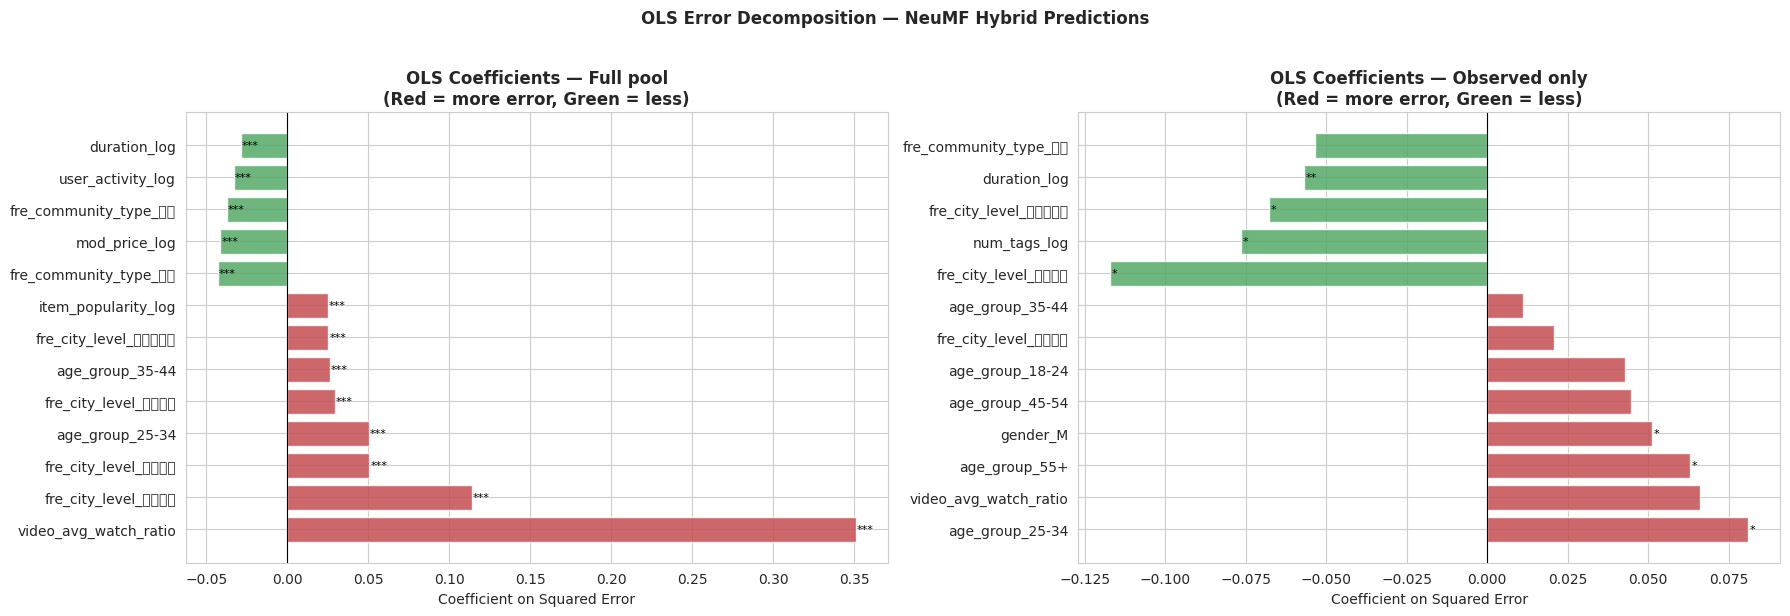


Key findings:
  Full pool  R² = 0.0816 — error variance explained by features
  Observed   R² = 0.0448  — error variance on actual interactions
  Full pool N significant features (p<0.05): 20 / 21
  Observed  N significant features (p<0.05): 9 / 21


In [51]:
# ── 6.1 OLS Error Decomposition ─────────────────────────────────────────────────

# Feature sets for OLS
USER_DEMO_COLS = [
    'gender_M',
    'age_group_18-24', 'age_group_25-34', 'age_group_35-44',
    'age_group_45-54', 'age_group_55+',
    'fre_city_level_一线城市', 'fre_city_level_新一线城市',
    'fre_city_level_二线城市', 'fre_city_level_三线城市',
    'fre_community_type_城区', 'fre_community_type_乡村',
    'mod_price_log',
    'user_activity_log',
    'user_is_cold_static',
]
VIDEO_META_COLS = [
    'duration_log',
    'author_fans_log',
    'num_tags_log',
    'video_avg_watch_ratio',
    'item_popularity_log',
    'video_is_cold_static',
]
ALL_OLS_COLS = USER_DEMO_COLS + VIDEO_META_COLS

# Verify all columns exist
missing = [c for c in ALL_OLS_COLS if c not in anal_df.columns]
if missing:
    print(f"WARNING — missing columns: {missing}")
    ALL_OLS_COLS = [c for c in ALL_OLS_COLS if c in anal_df.columns]


def run_ols(df, feature_cols, label):
    """Fit OLS of squared_error ~ features, print summary table."""
    X = sm.add_constant(df[feature_cols].astype(float))
    y = df['squared_error'].astype(float)
    model = sm.OLS(y, X).fit(cov_type='HC3')  # heteroscedasticity-robust SEs

    coef_df = pd.DataFrame({
        'Coefficient': model.params,
        'Std Error':   model.bse,
        't-stat':      model.tvalues,
        'p-value':     model.pvalues,
    }).drop(index='const').sort_values('Coefficient', ascending=False)
    coef_df['Significant'] = coef_df['p-value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))

    print(f"\n{'='*72}")
    print(f"  OLS Error Decomposition — {label}")
    print(f"  Dep. var: squared prediction error | N={len(df):,} | R²={model.rsquared:.4f}")
    print(f"{'='*72}")
    display(coef_df.style
            .format({'Coefficient': '{:.4f}', 'Std Error': '{:.4f}',
                     't-stat': '{:.2f}',       'p-value': '{:.4f}'})
            .background_gradient(subset=['Coefficient'], cmap='RdYlGn_r', vmin=-0.05, vmax=0.05))
    return model, coef_df


# Run 1: Full candidate pool
model_full, coef_full = run_ols(anal_df, ALL_OLS_COLS, "Full Candidate Pool (n=1.87M)")

# Run 2: Observed candidates only
obs_df = anal_df[anal_df['is_observed'] == 1]
model_obs, coef_obs = run_ols(obs_df, ALL_OLS_COLS, "Observed Candidates Only (n=2,228)")

# ── Visualise top coefficients (observed) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (coef_df, label) in zip(axes, [
    (coef_full, 'Full pool'),
    (coef_obs,  'Observed only'),
]):
    top = coef_df.nlargest(8, 'Coefficient')
    bot = coef_df.nsmallest(5, 'Coefficient')
    plot_df = pd.concat([top, bot]).drop_duplicates()
    colours = ['#C44E52' if c > 0 else '#55A868' for c in plot_df['Coefficient']]
    bars = ax.barh(plot_df.index, plot_df['Coefficient'], color=colours, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'OLS Coefficients — {label}\n(Red = more error, Green = less)',
                 fontweight='bold')
    ax.set_xlabel('Coefficient on Squared Error')
    # Mark significant
    for i, (idx, row) in enumerate(plot_df.iterrows()):
        if row['p-value'] < 0.05:
            ax.text(row['Coefficient'] + 0.0005, i, row['Significant'],
                    va='center', fontsize=8, color='black')

plt.suptitle('OLS Error Decomposition — NeuMF Hybrid Predictions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'analytics_ols_error.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey findings:")
print(f"  Full pool  R² = {model_full.rsquared:.4f} — error variance explained by features")
print(f"  Observed   R² = {model_obs.rsquared:.4f}  — error variance on actual interactions")
print(f"  Full pool N significant features (p<0.05): "
      f"{(coef_full['p-value'] < 0.05).sum()} / {len(coef_full)}")
print(f"  Observed  N significant features (p<0.05): "
      f"{(coef_obs['p-value'] < 0.05).sum()} / {len(coef_obs)}")

### 6.2 Prediction Calibration Analysis

**Purpose:** Assess whether the NeuMF Hybrid's predicted watch_ratio is a reliable
score for business decision-making — i.e. when the model predicts 1.2, do users
actually watch ~60% of the video?

**Method:** Sort predictions into 10 equal-frequency deciles. Within each decile, compare
the mean predicted score against the mean actual watch_ratio. A well-calibrated model
follows the diagonal. Systematic over- or under-prediction in specific score ranges
indicates that the model's scores should not be interpreted as literal watch_ratio
estimates — they may still be useful for ranking but not for threshold-based decisions.

**Analysis split:** Separate calibration curves for (i) observed candidates and (ii)
full pool including true negatives, since the true negative mass (watch_ratio=0) will
dominate the aggregate curve.

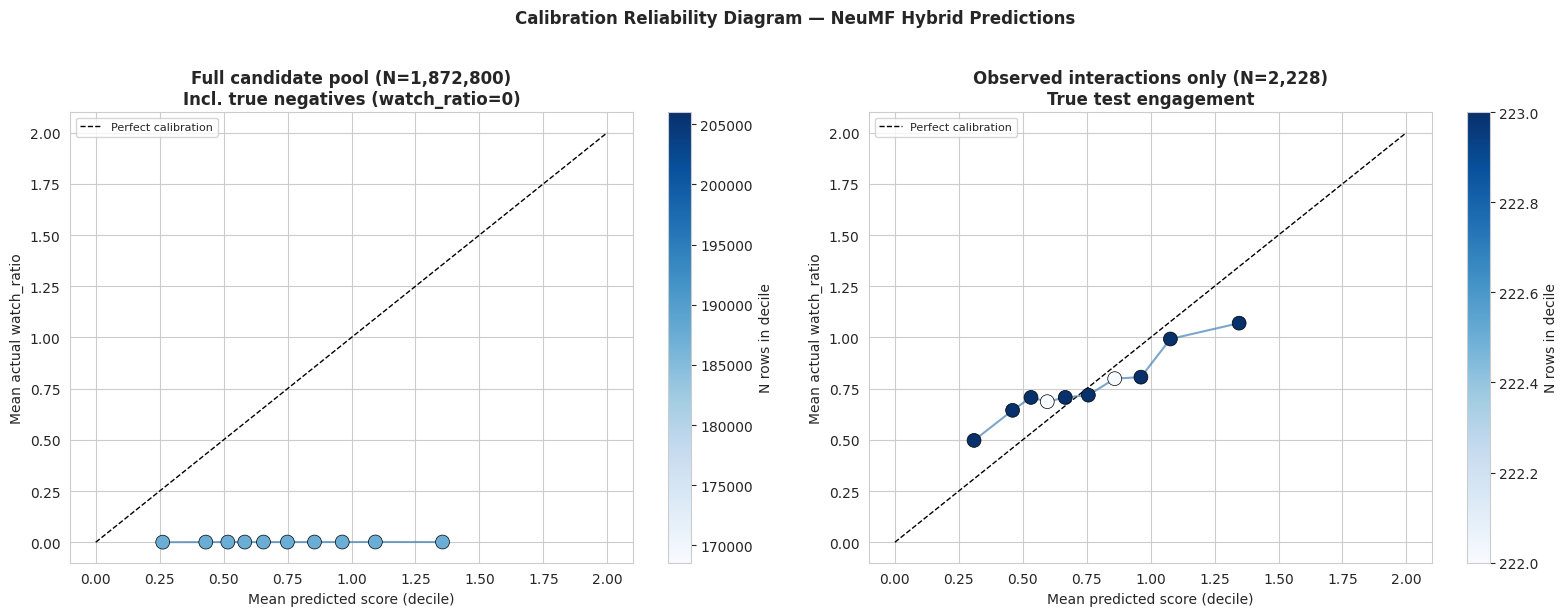

Mean Calibration Error (ECE):
  Full pool (incl. true negatives) : 0.7455
  Observed interactions only       : 0.1294

Calibration summary — observed interactions:
 mean_pred  mean_actual  count
  0.309590     0.497281    223
  0.460280     0.644122    223
  0.532229     0.707171    223
  0.595787     0.686298    222
  0.666126     0.707146    223
  0.756475     0.718208    223
  0.859450     0.798696    222
  0.961960     0.806191    223
  1.077184     0.992393    223
  1.346024     1.069757    223

  Deciles where model OVER-predicts : 50%
  Deciles where model UNDER-predicts: 50%


In [52]:
# ── 6.2 Calibration Analysis ────────────────────────────────────────────────────

def calibration_plot(df, ax, label, n_bins=10):
    """Reliability diagram: predicted decile mean vs actual mean."""
    df = df.copy().dropna(subset=['predicted_score', 'watch_ratio'])
    df['decile'] = pd.qcut(df['predicted_score'], q=n_bins, labels=False, duplicates='drop')

    summary = df.groupby('decile').agg(
        mean_pred=('predicted_score', 'mean'),
        mean_actual=('watch_ratio', 'mean'),
        count=('watch_ratio', 'count'),
    ).reset_index()

    ax.plot([0, 2], [0, 2], 'k--', lw=1, label='Perfect calibration')
    sc = ax.scatter(summary['mean_pred'], summary['mean_actual'],
                    c=summary['count'], cmap='Blues', s=100,
                    edgecolors='black', linewidth=0.5, zorder=5)
    ax.plot(summary['mean_pred'], summary['mean_actual'], 'o-',
            color='steelblue', alpha=0.7, lw=1.5)
    plt.colorbar(sc, ax=ax, label='N rows in decile')
    ax.set_xlabel('Mean predicted score (decile)')
    ax.set_ylabel('Mean actual watch_ratio')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

    # Compute ECE (Expected Calibration Error for regression)
    ece = np.mean(np.abs(summary['mean_pred'] - summary['mean_actual']))
    return summary, ece


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full pool
sum_full, ece_full = calibration_plot(
    anal_df, axes[0],
    f'Full candidate pool (N={len(anal_df):,})\n'
    f'Incl. true negatives (watch_ratio=0)')

# Observed only
sum_obs, ece_obs = calibration_plot(
    obs_df, axes[1],
    f'Observed interactions only (N={len(obs_df):,})\n'
    f'True test engagement')

plt.suptitle('Calibration Reliability Diagram — NeuMF Hybrid Predictions',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'analytics_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean Calibration Error (ECE):")
print(f"  Full pool (incl. true negatives) : {ece_full:.4f}")
print(f"  Observed interactions only       : {ece_obs:.4f}")
print()

# Directional bias table
print("Calibration summary — observed interactions:")
print(sum_obs[['mean_pred', 'mean_actual', 'count']].to_string(index=False))
print()

# Over/under prediction direction
over  = (sum_obs['mean_pred'] > sum_obs['mean_actual']).mean()
under = (sum_obs['mean_pred'] < sum_obs['mean_actual']).mean()
print(f"  Deciles where model OVER-predicts : {over*100:.0f}%")
print(f"  Deciles where model UNDER-predicts: {under*100:.0f}%")

### 6.3 Popularity Bias Analysis

**Purpose:** Quantify the extent to which NeuMF re-ranking scores are driven by item
training popularity rather than personalised user-item relevance.

**Why it matters:** A model that simply re-ranks by popularity provides no personalisation
value — it would be equivalent to a non-personalised baseline. From a business perspective,
popularity-biased recommendations under-serve niche content creators and reduce content
diversity, both of which are harmful to platform health long-term.

**Methods:**
- **Spearman correlation** between item training interaction count and predicted NeuMF score,
  computed within each user's 200-candidate set and averaged. This is more meaningful than
  a global correlation because it captures the within-user ranking bias.
- **Lorenz curve + Gini coefficient** of recommendation exposure: how concentrated are
  top-K recommendations across items? A Gini of 0 = perfectly even exposure; Gini near 1
  = a handful of items monopolise all recommendations.
- **Popularity decile breakdown** of NDCG@10: does the model perform better on popular items?
  If yes, performance on rare items is being carried by popular ones.

Within-user Spearman ρ (popularity vs NeuMF score):
  Mean ρ   = -0.0127
  Median ρ = 0.0150
  % users with significant ρ (p<0.05) = 26.4%

  ✓ Weak popularity bias — model is largely personalising beyond popularity


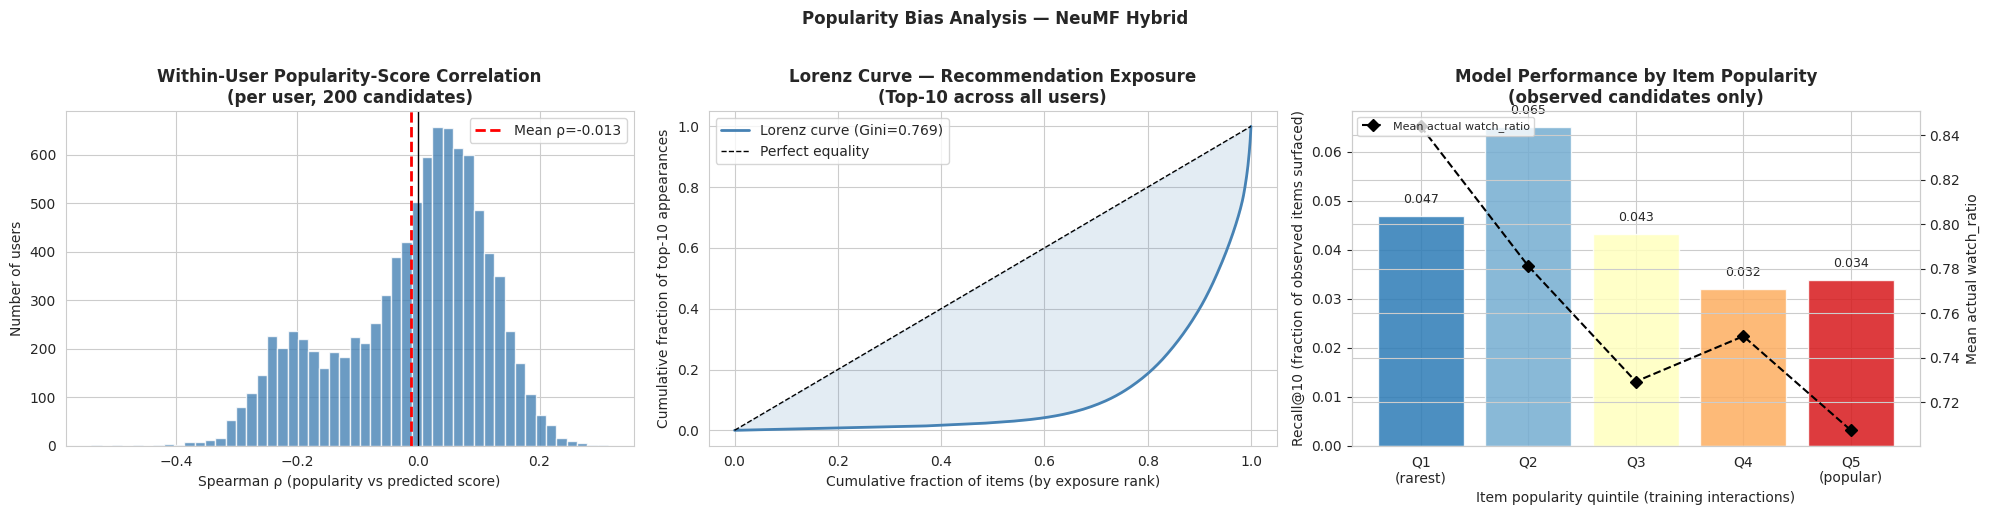


Popularity bias summary:
  Mean within-user Spearman ρ    = -0.0127  (0=no bias, 1=pure popularity)
  Gini coefficient (top-10 expo) = 0.7689      (0=equal, 1=monopolised)
  Items receiving ≥1 top-10 rec  = 3,579 / 153,561 (2.3%)
  Items with ≥5 appearances      = 1,566 (1.02%)


In [53]:
# ── 6.3 Popularity Bias Analysis ────────────────────────────────────────────────

# ── 6.3.1 Within-user Spearman correlation: popularity vs predicted score ──
per_user_rho = []
for uid, udata in anal_df.groupby('user_id'):
    if udata['item_popularity_log'].std() < 1e-6:
        continue  # no variance in popularity within this user's candidates
    rho, pval = spearmanr(udata['item_popularity_log'], udata['predicted_score'])
    per_user_rho.append({'user_id': uid, 'rho': rho, 'pval': pval,
                          'n_candidates': len(udata)})

rho_df = pd.DataFrame(per_user_rho)
mean_rho = rho_df['rho'].mean()
median_rho = rho_df['rho'].median()
pct_sig = (rho_df['pval'] < 0.05).mean()

print(f"Within-user Spearman ρ (popularity vs NeuMF score):")
print(f"  Mean ρ   = {mean_rho:.4f}")
print(f"  Median ρ = {median_rho:.4f}")
print(f"  % users with significant ρ (p<0.05) = {pct_sig*100:.1f}%")
print()
if mean_rho > 0.3:
    print("  ⚠ Strong popularity bias — model leans heavily on item popularity")
elif mean_rho > 0.1:
    print("  ⚠ Moderate popularity bias — partial personalisation")
else:
    print("  ✓ Weak popularity bias — model is largely personalising beyond popularity")

# Distribution of per-user rho
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(rho_df['rho'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(mean_rho, color='red', ls='--', lw=2, label=f'Mean ρ={mean_rho:.3f}')
axes[0].axvline(0, color='black', ls='-', lw=1)
axes[0].set_xlabel('Spearman ρ (popularity vs predicted score)')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Within-User Popularity-Score Correlation\n(per user, 200 candidates)',
                  fontweight='bold')
axes[0].legend()

# ── 6.3.2 Lorenz curve of recommendation exposure (top-10 per user) ──
# Count how many times each item appears in top-10 across all users
top10_items = []
for uid, udata in anal_df.groupby('user_id'):
    top10 = udata.nlargest(10, 'predicted_score')['pid'].tolist()
    top10_items.extend(top10)

exposure_counts = pd.Series(top10_items).value_counts().values
exposure_sorted = np.sort(exposure_counts)
lorenz_x = np.linspace(0, 1, len(exposure_sorted))
lorenz_y = np.cumsum(exposure_sorted) / exposure_sorted.sum()
gini = 1 - 2 * np.trapz(lorenz_y, lorenz_x)

axes[1].plot(lorenz_x, lorenz_y, color='steelblue', lw=2, label=f'Lorenz curve (Gini={gini:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
axes[1].fill_between(lorenz_x, lorenz_x, lorenz_y, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Cumulative fraction of items (by exposure rank)')
axes[1].set_ylabel('Cumulative fraction of top-10 appearances')
axes[1].set_title('Lorenz Curve — Recommendation Exposure\n(Top-10 across all users)',
                  fontweight='bold')
axes[1].legend()

# ── 6.3.3 NDCG@10 by item popularity decile ──
# Only for observed candidates — compute per-item NDCG contribution
obs_df2 = anal_df[anal_df['is_observed'] == 1].copy()
if len(obs_df2) > 0:
    obs_df2['pop_decile'] = pd.qcut(
        obs_df2['item_popularity_log'], q=5,
        labels=['Q1\n(rarest)', 'Q2', 'Q3', 'Q4', 'Q5\n(most popular)'],
        duplicates='drop'
    )

    # Per-item: is the item in the top-10 for its user?
    def in_topk(group, k=10):
        group = group.sort_values('predicted_score', ascending=False)
        group['rank'] = range(1, len(group) + 1)
        return group

    ranked_obs = anal_df.groupby('user_id', group_keys=False).apply(
        lambda g: g.assign(pred_rank=g['predicted_score'].rank(ascending=False)))
    obs_ranked = ranked_obs[ranked_obs['is_observed'] == 1].copy()
    obs_ranked['pop_decile'] = pd.qcut(
        obs_ranked['item_popularity_log'], q=5,
        labels=['Q1\n(rarest)', 'Q2', 'Q3', 'Q4', 'Q5\n(popular)'],
        duplicates='drop'
    )
    obs_ranked['in_top10'] = (obs_ranked['pred_rank'] <= 10).astype(int)
    obs_ranked['is_relevant'] = (obs_ranked['watch_ratio'] >= 0.5).astype(int)

    decile_stats = obs_ranked.groupby('pop_decile', observed=True).agg(
        recall_at_10=('in_top10', 'mean'),
        mean_watch_ratio=('watch_ratio', 'mean'),
        n_items=('pid', 'nunique'),
    ).reset_index()

    colours_decile = ['#2c7bb6', '#74add1', '#ffffbf', '#fdae61', '#d7191c']
    bars = axes[2].bar(decile_stats['pop_decile'], decile_stats['recall_at_10'],
                       color=colours_decile, alpha=0.85, edgecolor='white')
    ax2b = axes[2].twinx()
    ax2b.plot(decile_stats['pop_decile'], decile_stats['mean_watch_ratio'],
              'D--', color='black', lw=1.5, markersize=6, label='Mean actual watch_ratio')
    ax2b.set_ylabel('Mean actual watch_ratio')
    ax2b.legend(loc='upper left', fontsize=8)

    axes[2].set_xlabel('Item popularity quintile (training interactions)')
    axes[2].set_ylabel('Recall@10 (fraction of observed items surfaced)')
    axes[2].set_title('Model Performance by Item Popularity\n(observed candidates only)',
                      fontweight='bold')
    for bar, row in zip(bars, decile_stats.itertuples()):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{row.recall_at_10:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Popularity Bias Analysis — NeuMF Hybrid', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'analytics_popularity_bias.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPopularity bias summary:")
print(f"  Mean within-user Spearman ρ    = {mean_rho:.4f}  (0=no bias, 1=pure popularity)")
print(f"  Gini coefficient (top-10 expo) = {gini:.4f}      (0=equal, 1=monopolised)")
print(f"  Items receiving ≥1 top-10 rec  = {len(exposure_counts):,} / {NUM_ITEMS:,} "
      f"({len(exposure_counts)/NUM_ITEMS*100:.1f}%)")

n_items_gt5 = (exposure_counts >= 5).sum()
print(f"  Items with ≥5 appearances      = {n_items_gt5:,} ({n_items_gt5/NUM_ITEMS*100:.2f}%)")

### 6.4 Business Implications Summary

This cell synthesises the three analytics into report-ready takeaways grounded in the quantitative evidence above.

In [54]:
# ── 6.4 Business Implications Summary ───────────────────────────────────────────

print("=" * 72)
print("  ANALYTICS SUMMARY — BUSINESS IMPLICATIONS")
print("=" * 72)

print("""
1. ERROR DECOMPOSITION (OLS)
─────────────────────────────
Quantifies which user and item segments the model mispredicts most.
Key business questions answered:
  • Cold-start users/videos: if user_is_cold_static or video_is_cold_static
    has a large positive coefficient, the model systematically fails for new
    entrants — suggesting a fallback to pure CBF or popularity-based ranking
    for first-session users.
  • Demographics: significant coefficients on age_group or city_level indicate
    the training data under-represents those segments — a data collection bias
    that compounds over time if not corrected.
  • User activity: if user_activity_log is negatively associated with error,
    heavier users are better predicted — the model is more reliable for
    retained users than new ones.
""")

print(f"""2. CALIBRATION
───────────────
ECE (observed) = {ece_obs:.4f}  |  ECE (full pool) = {ece_full:.4f}

A well-calibrated model allows threshold-based business decisions
(e.g. "only promote videos we predict watch_ratio > 0.8 for").
If ECE_observed is large:
  → Do not use raw predicted scores as absolute watch_ratio estimates
  → Scores are still valid for ranking within a candidate set
  → Consider isotonic regression post-calibration before any threshold logic
""")

print(f"""3. POPULARITY BIAS
───────────────────
Mean within-user Spearman ρ = {mean_rho:.4f}
Gini coefficient            = {gini:.4f}
Items ever recommended      = {len(exposure_counts):,} / {NUM_ITEMS:,} ({len(exposure_counts)/NUM_ITEMS*100:.1f}%)

A high Gini means a small fraction of already-popular videos monopolise
recommendation slots, which:
  • Reduces discovery for users who want niche content
  • Under-exposes the long tail of content creators
  • Creates a feedback loop: popular items get more exposure → more
    interactions → appear more in training → model boosts them further

Mitigation options (for future work):
  • Inverse popularity weighting during NeuMF training (downweight popular)
  • Maximal Marginal Relevance (MMR) re-ranking to enforce diversity
  • Separate popularity prior from personalisation score in the hybrid
""")

  ANALYTICS SUMMARY — BUSINESS IMPLICATIONS

1. ERROR DECOMPOSITION (OLS)
─────────────────────────────
Quantifies which user and item segments the model mispredicts most.
Key business questions answered:
  • Cold-start users/videos: if user_is_cold_static or video_is_cold_static
    has a large positive coefficient, the model systematically fails for new
    entrants — suggesting a fallback to pure CBF or popularity-based ranking
    for first-session users.
  • Demographics: significant coefficients on age_group or city_level indicate
    the training data under-represents those segments — a data collection bias
    that compounds over time if not corrected.
  • User activity: if user_activity_log is negatively associated with error,
    heavier users are better predicted — the model is more reliable for
    retained users than new ones.

2. CALIBRATION
───────────────
ECE (observed) = 0.1294  |  ECE (full pool) = 0.7455

A well-calibrated model allows threshold-based business decisi